# Klasifikasi Kematangan Tapai - Linear Regression

Notebook ini menggunakan **Logistic Regression** (regresi linear untuk klasifikasi) dari scikit-learn untuk memprediksi status kematangan tapai berdasarkan data sensor (suhu, kelembaban, kadar gas) selama waktu fermentasi.

## Dataset
- **Fitur:** `jam`, `suhu`, `kelembaban`, `kadar_gas`
- **Target:** `status_kematangan` (belum matang, matang, terlalu matang)
- **10 percobaan**, masing-masing 60 jam pengamatan

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

plt.style.use('seaborn-v0_8')
print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Load & Eksplorasi Data

In [24]:
df = pd.read_csv('../dataset/dataset_kematangan_tapai_v2.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (600, 6)


,percobaan,jam,suhu,kelembaban,kadar_gas,status_kematangan
0,1,1,28.73,78.77,0.02,belum matang
1,1,2,28.51,78.62,0.01,belum matang
2,1,3,28.33,78.22,0.01,belum matang
3,1,4,29.20,78.46,0.01,belum matang
4,1,5,28.42,78.65,0.00,belum matang
5,1,6,28.48,78.93,0.02,belum matang
6,1,7,28.99,78.87,0.01,belum matang
7,1,8,28.50,79.07,0.01,belum matang
8,1,9,28.48,78.72,0.01,belum matang
9,1,10,28.53,78.97,0.01,belum matang


In [25]:
print('Info dataset:')
df.info()
print('\nDistribusi label:')
print(df['status_kematangan'].value_counts())

Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   percobaan          600 non-null    int64  
 1   jam                600 non-null    int64  
 2   suhu               600 non-null    float64
 3   kelembaban         600 non-null    float64
 4   kadar_gas          600 non-null    float64
 5   status_kematangan  600 non-null    str    
dtypes: float64(3), int64(2), str(1)
memory usage: 28.3 KB

Distribusi label:
status_kematangan
belum matang      417
terlalu matang    116
matang             67
Name: count, dtype: int64


In [26]:
df.describe()

,percobaan,jam,suhu,kelembaban,kadar_gas
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,5.500000,30.500000,28.550083,85.735017,0.224150
std,2.874678,17.332552,0.870029,5.697140,0.303721
min,1.000000,1.000000,26.240000,77.890000,0.000000
25%,3.000000,15.750000,27.947500,80.515000,0.010000
50%,5.500000,30.500000,28.545000,84.445000,0.020000
75%,8.000000,45.250000,29.110000,91.517500,0.360000
max,10.000000,60.000000,31.080000,96.910000,1.380000


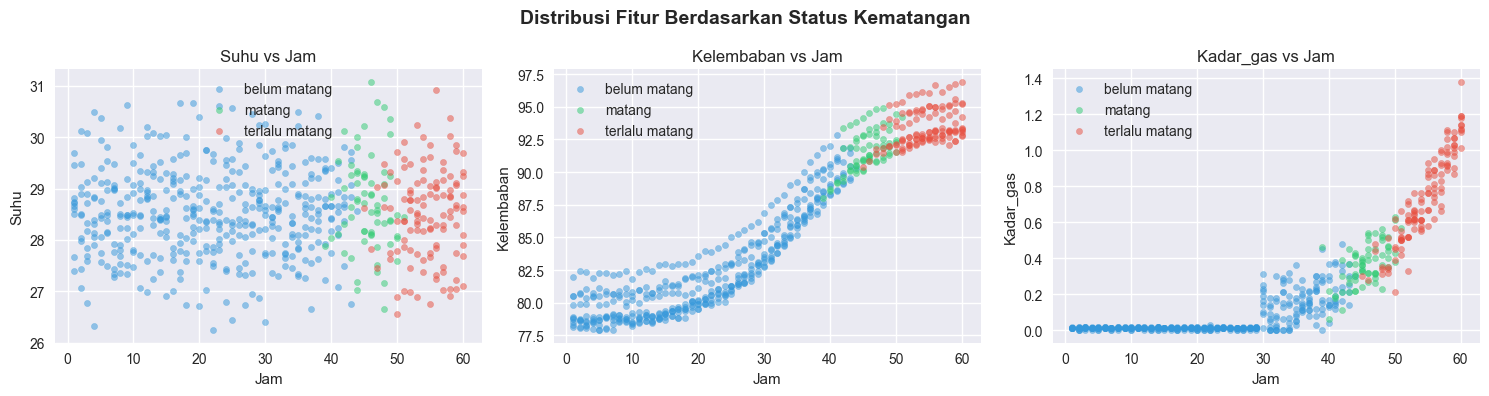

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'belum matang': '#3498db', 'matang': '#2ecc71', 'terlalu matang': '#e74c3c'}

for ax, col in zip(axes, ['suhu', 'kelembaban', 'kadar_gas']):
    for label, color in colors.items():
        subset = df[df['status_kematangan'] == label]
        ax.scatter(subset['jam'], subset[col], c=color, label=label, alpha=0.5, s=20)
    ax.set_xlabel('Jam')
    ax.set_ylabel(col.capitalize())
    ax.set_title(f'{col.capitalize()} vs Jam')
    ax.legend()

plt.suptitle('Distribusi Fitur Berdasarkan Status Kematangan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_linear_regression_eda.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Preprocessing

In [28]:
# Encode label
label_map = {'belum matang': 0, 'matang': 1, 'terlalu matang': 2}
df['label'] = df['status_kematangan'].map(label_map)

# Fitur dan target
X = df[['jam', 'kelembaban', 'kadar_gas']].values
y = df['label'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisasi
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (480, 3), Test: (120, 3)


## 3. Training Model - Logistic Regression

In [29]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')

Accuracy: 0.9250 (92.50%)


## 4. Evaluasi Model

In [30]:
target_names = ['belum matang', 'matang', 'terlalu matang']
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report:
                precision    recall  f1-score   support

  belum matang       0.98      0.98      0.98        84
        matang       0.62      0.77      0.69        13
terlalu matang       0.95      0.83      0.88        23

      accuracy                           0.93       120
     macro avg       0.85      0.86      0.85       120
  weighted avg       0.93      0.93      0.93       120



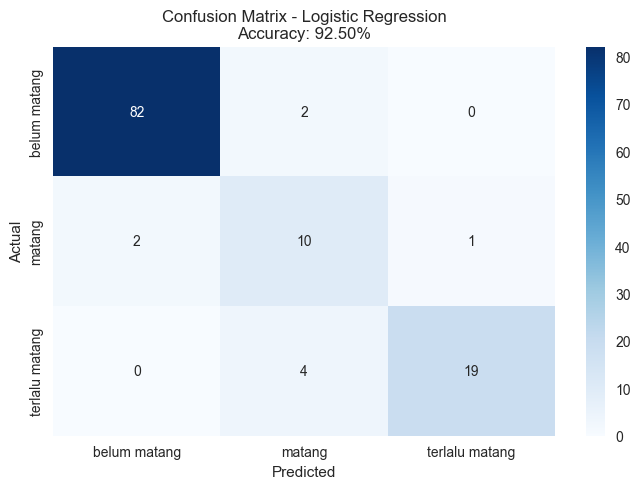

In [31]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - Logistic Regression\nAccuracy: {accuracy*100:.2f}%')
plt.tight_layout()
plt.savefig('plot_linear_regression_cm.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Visualisasi Koefisien

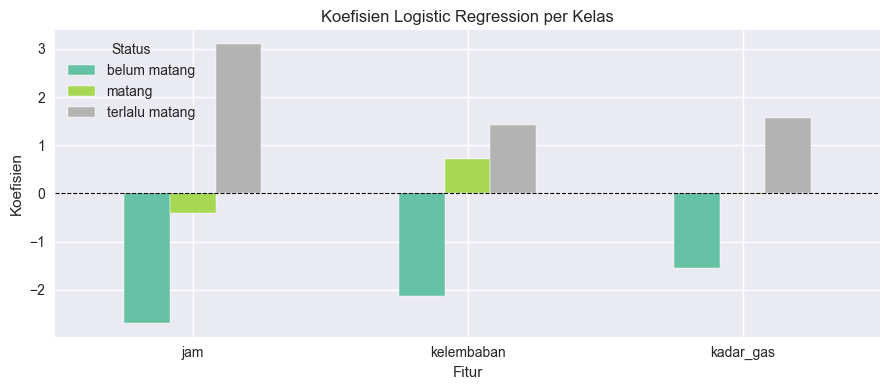

In [32]:
feature_names = ['jam', 'kelembaban', 'kadar_gas']
coef_df = pd.DataFrame(model.coef_, columns=feature_names, index=target_names)

fig, ax = plt.subplots(figsize=(9, 4))
coef_df.T.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_xlabel('Fitur')
ax.set_ylabel('Koefisien')
ax.set_title('Koefisien Logistic Regression per Kelas')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(title='Status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot_linear_regression_coef.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Kesimpulan

| Metrik | Nilai |
|--------|-------|
| Model | Logistic Regression (Linear) |
| Fitur | jam, suhu, kelembaban, kadar_gas |
| Split | 80% train / 20% test |

**Catatan:** Logistic Regression merupakan model linear untuk klasifikasi. Model ini mengasumsikan batas keputusan yang linear antar kelas dan **tidak mempertimbangkan urutan waktu** (data tiap jam dianggap independen). Hal ini menjadi keterbatasan utama karena data kematangan tapai sangat bergantung pada runtutan waktu fermentasi.